1. Import Library

In [57]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

# LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except:
    LGBM_OK = False

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except:
    XGBOOST_OK = False

print('Library berhasil dipanggil')

Library berhasil dipanggil


2. Membaca Dataset

In [58]:
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

print(f'Data training : {df_train.shape[0]} baris dan {df_train.shape[1]} kolom')
print(f'Data testing  : {df_test.shape[0]} baris dan {df_test.shape[1]} kolom')

# Menampilkan 5 data pertama

df_train.head()

Data training : 857 baris dan 13 kolom
Data testing  : 286 baris dan 12 kolom


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


3. Distribusi Target

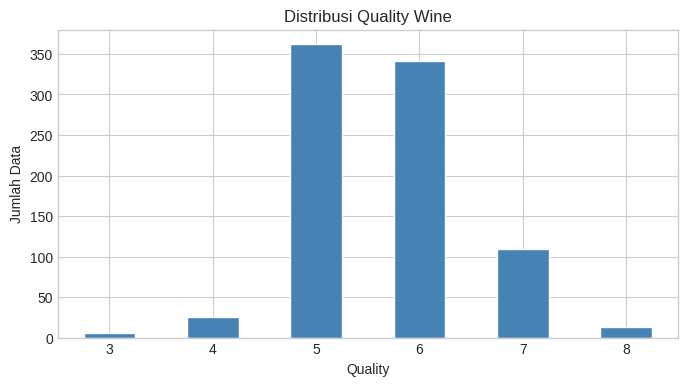

Distribusi data masih belum seimbang.
Beberapa kelas memiliki jumlah data yang sedikit.


In [59]:
quality_counts = df_train['quality'].value_counts().sort_index()

plt.figure(figsize=(8,4))

quality_counts.plot(
    kind='bar',
    color='steelblue',
    edgecolor='white'
)

plt.title('Distribusi Quality Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

plt.show()

print('Distribusi data masih belum seimbang.')
print('Beberapa kelas memiliki jumlah data yang sedikit.')

4. Heatmap Korelasi

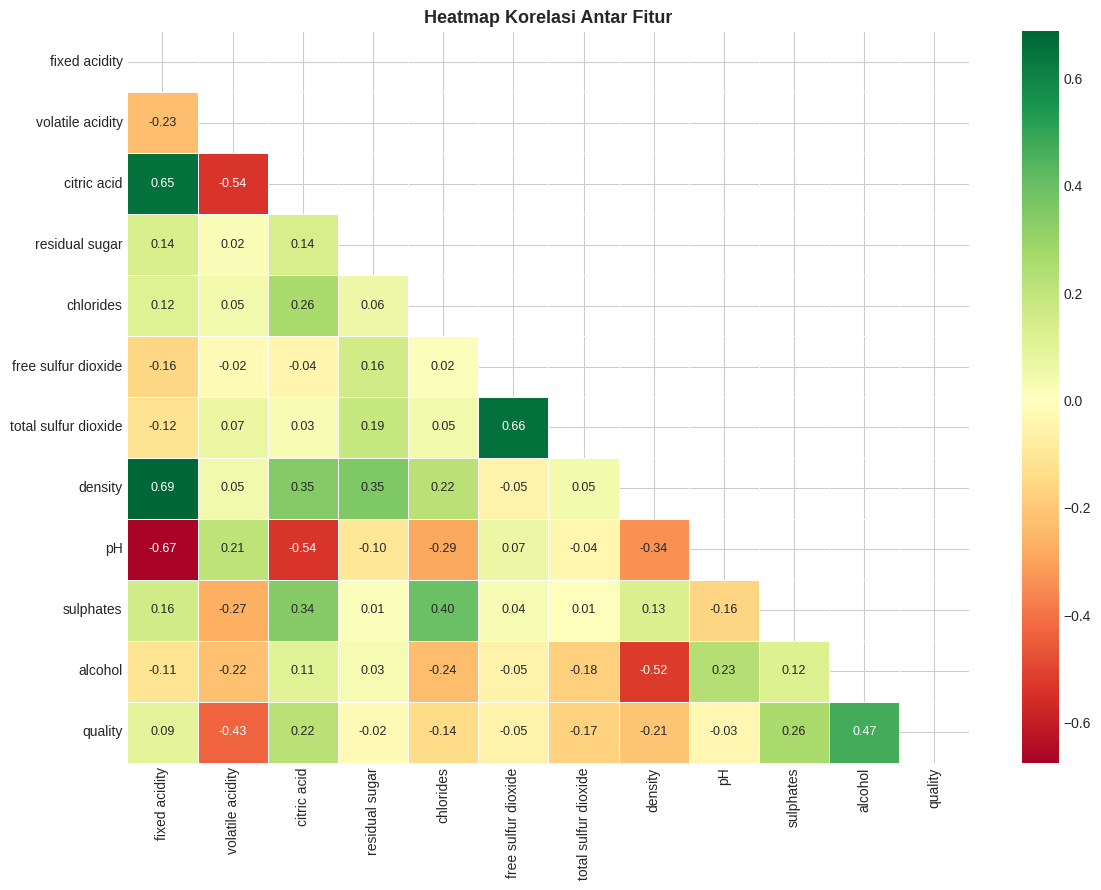

Korelasi fitur terhadap quality (diurutkan):
alcohol                 0.474
volatile acidity       -0.430
sulphates               0.261
citric acid             0.221
density                -0.208
total sulfur dioxide   -0.173
chlorides              -0.145
fixed acidity           0.093
free sulfur dioxide    -0.055
pH                     -0.033
residual sugar         -0.021


In [60]:
# Heatmap korelasi
plt.figure(figsize=(12, 9))
corr = df_train.drop(columns=['Id']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Korelasi fitur terhadap quality (diurutkan):')
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False).round(3).to_string())

5. Data Cleaning

In [61]:
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides',
    'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

print('Missing value training :', df_train[feature_cols].isnull().sum().sum())
print('Missing value testing  :', df_test[feature_cols].isnull().sum().sum())
print('Data duplikat training :', df_train.duplicated().sum())

for col in feature_cols:

    if df_train[col].isnull().any():

        median_value = df_train[col].median()

        df_train[col].fillna(median_value, inplace=True)
        df_test[col].fillna(median_value, inplace=True)

print('Data cleaning selesai')

Missing value training : 0
Missing value testing  : 0
Data duplikat training : 0
Data cleaning selesai


6. Feature Engineering

In [62]:
def add_features(df):

    df = df.copy()

    df['alcohol_sulphates'] = df['alcohol'] * df['sulphates']

    df['acid_ratio'] = (
        df['fixed acidity'] /
        (df['volatile acidity'] + 1e-6)
    )

    df['so2_ratio'] = (
        df['free sulfur dioxide'] /
        (df['total sulfur dioxide'] + 1e-6)
    )

    df['total_acidity'] = (
        df['fixed acidity'] +
        df['volatile acidity']
    )

    return df


# Menambahkan fitur baru

X_fe = add_features(df_train[feature_cols])
X_te_fe = add_features(df_test[feature_cols])

# Membuat target klasifikasi

y = df_train['quality'].apply(
    lambda x: 1 if x >= 6 else 0
)

print('Jumlah fitur awal   :', len(feature_cols))
print('Jumlah fitur akhir  :', X_fe.shape[1])

Jumlah fitur awal   : 11
Jumlah fitur akhir  : 15


7. Scaling dan SMOTE

In [63]:
scaler = StandardScaler()

X_sc = scaler.fit_transform(X_fe)
Xte_sc = scaler.transform(X_te_fe)

smote = SMOTE(random_state=42)

X_sc, y = smote.fit_resample(X_sc, y)

X_train, X_val, y_train, y_val = train_test_split(
    X_sc,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Scaling dan SMOTE selesai')
print(f'Data training : {X_train.shape[0]}')
print(f'Data validasi : {X_val.shape[0]}')

Scaling dan SMOTE selesai
Data training : 740
Data validasi : 186


8. Cross Validation Model

In [64]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=1000,
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=1000,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

if LGBM_OK:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )

if XGBOOST_OK:
    models['XGBoost'] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )

# Cross validation
cv_results = {}

print('=== Cross Validation Results ===')

for name, model in models.items():

    yy = (y - y.min()) if name == 'XGBoost' else y

    scores = cross_val_score(
        model,
        X_sc,
        yy,
        cv=cv,
        scoring='accuracy'
    )

    cv_results[name] = scores

    print(f'{name}: {scores.mean():.4f}')

# Model terbaik
best_name = max(cv_results, key=lambda k: cv_results[k].mean())

print(f'\nModel terbaik: {best_name}')

=== Cross Validation Results ===
Random Forest: 0.8056
Extra Trees: 0.8067
Gradient Boosting: 0.7829
LightGBM: 0.8002
XGBoost: 0.7959

Model terbaik: Extra Trees


9. Visualisasi Perbandingn

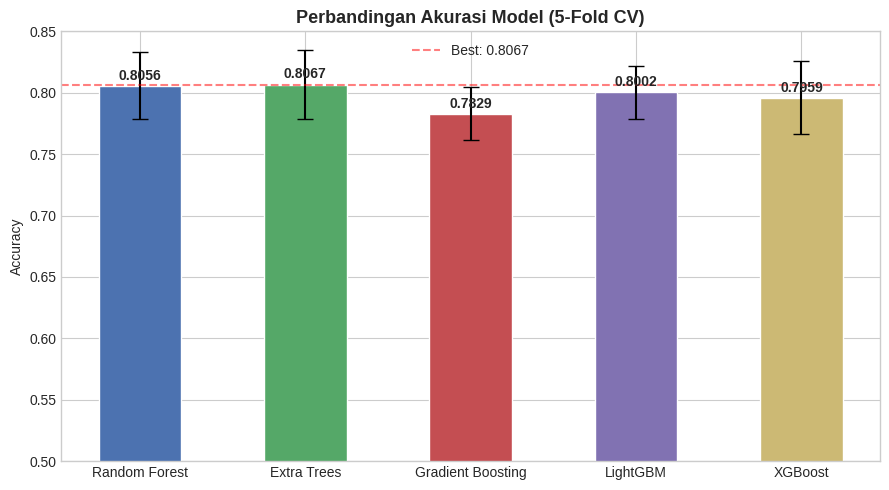

In [65]:
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

plt.figure(figsize=(9, 5))
bars = plt.bar(names, means, yerr=stds, capsize=6, color=colors[:len(names)],
               edgecolor='white', width=0.5)
plt.ylim(0.5, 0.85)
plt.title('Perbandingan Akurasi Model (5-Fold CV)', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.axhline(max(means), color='red', linestyle='--', alpha=0.5,
            label=f'Best: {max(means):.4f}')
plt.legend()
for bar, m in zip(bars, means):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{m:.4f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

10. Confusion Matrix

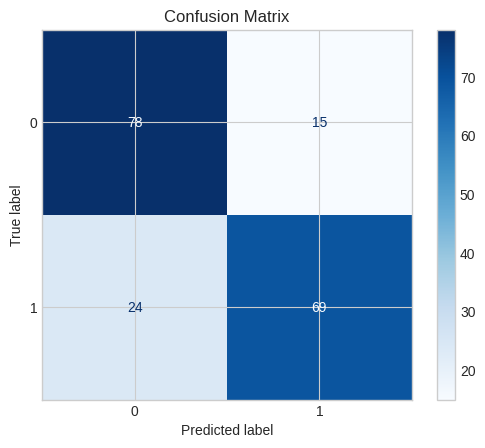

In [66]:
cm = confusion_matrix(y_val, y_pred_val)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()

11. Feature Importance

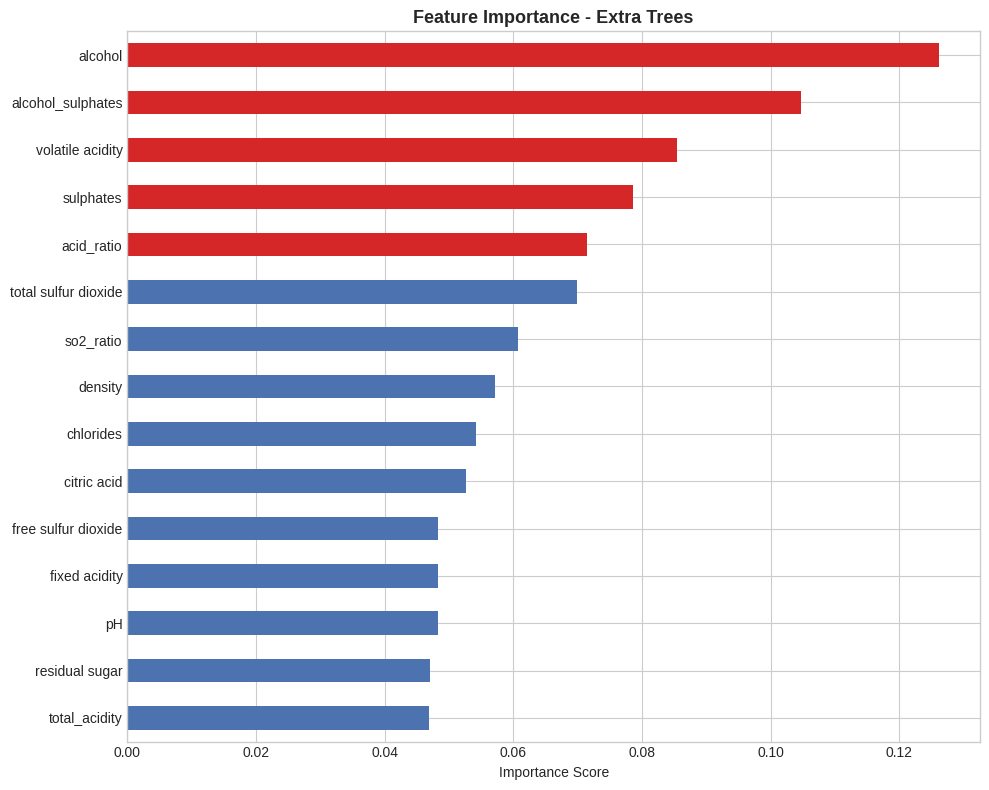

Top 5 Fitur Paling Penting:
  alcohol                       : 0.1262
  alcohol_sulphates             : 0.1048
  volatile acidity              : 0.0854
  sulphates                     : 0.0786
  acid_ratio                    : 0.0715


In [67]:
importances = pd.Series(best_model.feature_importances_, index=list(X_fe.columns))
imp_sorted  = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors_bar = ['#d62728' if i >= len(imp_sorted)-5 else '#4C72B0'
              for i in range(len(imp_sorted))]
imp_sorted.plot(kind='barh', color=colors_bar)
plt.title('Feature Importance - Extra Trees', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('Top 5 Fitur Paling Penting:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<30}: {imp:.4f}')

12. Retrain dengan data testing

Retrain adalah proses melatih ulang model terbaik menggunakan seluruh data training setelah evaluasi selesai dilakukan. Tujuannya agar model bisa belajar dari lebih banyak data sehingga hasil prediksi menjadi lebih optimal. Setelah retrain selesai, model kemudian digunakan untuk memprediksi data testing.

In [68]:
final_model = ExtraTreesClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
final_model.fit(X_sc, y)

y_pred_test = final_model.predict(Xte_sc)

print(f'Prediksi selesai untuk {len(y_pred_test)} data.')
print('Distribusi Hasil Prediksi:')
dist = pd.Series(y_pred_test).value_counts().sort_index()
for q, cnt in dist.items():
    print(f'  Quality {q}: {cnt:>4} sampel')

Prediksi selesai untuk 286 data.
Distribusi Hasil Prediksi:
  Quality 0:  133 sampel
  Quality 1:  153 sampel


In [69]:
output_filename = 'hasilprediksi_017.csv'

df_result = pd.DataFrame({
    'Id'     : df_test['Id'].values,
    'Quality': y_pred_test
})

df_result.to_csv(output_filename, index=False)

verify = pd.read_csv(output_filename)
print(f'File disimpan : {output_filename}')
print(f'Baris         : {len(verify)}')
print(f'Kolom         : {list(verify.columns)}')
print()
print('10 baris pertama:')
print(verify.head(10).to_string(index=False))

File disimpan : hasilprediksi_017.csv
Baris         : 286
Kolom         : ['Id', 'Quality']

10 baris pertama:
  Id  Quality
 222        0
1514        1
 417        0
 754        0
 516        1
1120        1
 180        0
  82        0
 632        1
 592        0


13. Export dan Download Hasil

In [70]:
df_result = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': y_pred_test
})

output_csv = 'hasilprediksi_017.csv'

df_result.to_csv(
    output_csv,
    index=False
)

print(f'File CSV berhasil disimpan: {output_csv}')

from google.colab import files

files.download(output_csv)

File CSV berhasil disimpan: hasilprediksi_017.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>